In [2]:
import pandas as pd
import numpy as np

# Load datasets
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")
customers = pd.read_csv("../data/raw/customers.csv")

print("Orders shape:", orders.shape)
print("Deliveries shape:", deliveries.shape)
print("Restaurants shape:", restaurants.shape)
print("Customers shape:", customers.shape)

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

print("\nRestaurants columns:")
print(restaurants.columns.tolist())

print("\nCustomers columns:")
print(customers.columns.tolist())

print("\n--- ORDERS ---")
display(orders.head())

print("\n--- DELIVERIES ---")
display(deliveries.head())

print("\n--- RESTAURANTS ---")
display(restaurants.head())

print("\n--- CUSTOMERS ---")
display(customers.head())

Orders shape: (100000, 8)
Deliveries shape: (90002, 10)
Restaurants shape: (500, 7)
Customers shape: (10000, 6)

Orders columns:
['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'item_count', 'payment_method', 'order_status']

Deliveries columns:
['delivery_id', 'order_id', 'driver_id', 'delivery_distance_km', 'preparation_time_min', 'delivery_time_min', 'traffic_condition', 'weather', 'tip_amount', 'delivery_status']

Restaurants columns:
['restaurant_id', 'restaurant_name', 'city', 'cuisine', 'restaurant_rating', 'avg_prep_time', 'price_range']

Customers columns:
['customer_id', 'age', 'gender', 'city', 'signup_date', 'membership_type']

--- ORDERS ---


,order_id,customer_id,restaurant_id,order_timestamp,order_amount,item_count,payment_method,order_status
0,O000001,C001469,R00176,2025-06-13 19:00:00,505.66,3,Cash,Completed
1,O000002,C001001,R00213,2025-05-27 21:00:00,601.49,3,UPI,Completed
2,O000003,C002237,R00303,2025-09-29 11:00:00,1611.51,6,Wallet,Completed
3,O000004,C000983,R00497,2025-11-19 22:00:00,416.92,2,UPI,Completed
4,O000005,C005138,R00133,2025-11-06 13:00:00,1309.67,7,Debit Card,Cancelled



--- DELIVERIES ---


,delivery_id,order_id,driver_id,delivery_distance_km,preparation_time_min,delivery_time_min,traffic_condition,weather,tip_amount,delivery_status
0,DL000001,O000001,D00644,5.12,44,52,Low,Cloudy,56.38,Completed
1,DL000002,O000002,D00598,3.28,30,28,Low,Clear,86.60,Completed
2,DL000003,O000003,D00937,2.98,30,19,Low,Cloudy,179.94,Completed
3,DL000004,O000004,D00717,2.02,34,42,Low,Clear,34.17,Completed
4,DL000005,O000007,D00059,5.70,21,56,High,Clear,8.24,Completed



--- RESTAURANTS ---


,restaurant_id,restaurant_name,city,cuisine,restaurant_rating,avg_prep_time,price_range
0,R00001,"Choudhury, Bakshi and Maharaj",Pune,Desserts,4.35,35,Low
1,R00002,Kapoor and Sons,Bangalore,Healthy,4.08,36,Low
2,R00003,"Chaudry, Chahal and Sami",Ahmedabad,Biryani,3.92,43,Medium
3,R00004,Balan Inc,Jaipur,Fast Food,3.70,32,Low
4,R00005,Kaul PLC,Jaipur,South Indian,3.41,25,High



--- CUSTOMERS ---


,customer_id,age,gender,city,signup_date,membership_type
0,C000001,56,Female,Chennai,2025-05-07,Premium
1,C000002,69,Male,Pune,2026-06-25,Gold
2,C000003,46,Female,Delhi,2025-07-17,Standard
3,C000004,32,Male,Chennai,2026-04-27,Gold
4,C000005,60,Female,Kochi,2025-06-28,Gold


In [3]:
# ============================================
# DAY 4 - DELIVERY TIME PREDICTION
# STEP 2: BUILD MODELING DATASET
# ============================================

import pandas as pd
import numpy as np

# Load datasets
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")

# Convert timestamp
orders["order_timestamp"] = pd.to_datetime(orders["order_timestamp"])

# Create time-based features
orders["hour"] = orders["order_timestamp"].dt.hour
orders["day_of_week"] = orders["order_timestamp"].dt.dayofweek

# Merge deliveries with orders
df = deliveries.merge(
    orders[
        [
            "order_id",
            "restaurant_id",
            "order_timestamp",
            "order_amount",
            "item_count",
            "order_status",
            "hour",
            "day_of_week"
        ]
    ],
    on="order_id",
    how="inner"
)

# Merge restaurant information
df = df.merge(
    restaurants[
        [
            "restaurant_id",
            "cuisine",
            "restaurant_rating",
            "avg_prep_time",
            "price_range"
        ]
    ],
    on="restaurant_id",
    how="left"
)

print("Merged dataset shape:", df.shape)

display(df.head())

Merged dataset shape: (90002, 21)


,delivery_id,order_id,driver_id,delivery_distance_km,preparation_time_min,delivery_time_min,traffic_condition,weather,tip_amount,delivery_status,...,order_timestamp,order_amount,item_count,order_status,hour,day_of_week,cuisine,restaurant_rating,avg_prep_time,price_range
0,DL000001,O000001,D00644,5.12,44,52,Low,Cloudy,56.38,Completed,...,2025-06-13 19:00:00,505.66,3,Completed,19,4,Italian,5.00,47,Medium
1,DL000002,O000002,D00598,3.28,30,28,Low,Clear,86.60,Completed,...,2025-05-27 21:00:00,601.49,3,Completed,21,1,Fast Food,3.61,30,Medium
2,DL000003,O000003,D00937,2.98,30,19,Low,Cloudy,179.94,Completed,...,2025-09-29 11:00:00,1611.51,6,Completed,11,0,Biryani,4.04,32,Medium
3,DL000004,O000004,D00717,2.02,34,42,Low,Clear,34.17,Completed,...,2025-11-19 22:00:00,416.92,2,Completed,22,2,Fast Food,3.03,34,Medium
4,DL000005,O000007,D00059,5.70,21,56,High,Clear,8.24,Completed,...,2026-02-24 11:00:00,325.11,2,Completed,11,1,Fast Food,3.57,23,Low


In [4]:
# ============================================
# CHECK MERGE QUALITY
# ============================================

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique orders:", df["order_id"].nunique())

print("\nDelivery status:")
print(df["delivery_status"].value_counts())

print("\nOrder status:")
print(df["order_status"].value_counts())

Rows: 90002
Columns: 21

Missing values:
delivery_id             0
order_id                0
driver_id               0
delivery_distance_km    0
preparation_time_min    0
delivery_time_min       0
traffic_condition       0
weather                 0
tip_amount              0
delivery_status         0
restaurant_id           0
order_timestamp         0
order_amount            0
item_count              0
order_status            0
hour                    0
day_of_week             0
cuisine                 0
restaurant_rating       0
avg_prep_time           0
price_range             0
dtype: int64

Duplicate rows: 0

Unique orders: 90002

Delivery status:
delivery_status
Completed    90002
Name: count, dtype: int64

Order status:
order_status
Completed    90002
Name: count, dtype: int64


In [5]:
df = df[df["delivery_status"] == "Completed"].copy()

In [6]:
print("Completed deliveries:", len(df))
print(df["delivery_time_min"].describe())

Completed deliveries: 90002
count    90002.000000
mean        52.143786
std         16.050667
min         10.000000
25%         41.000000
50%         51.000000
75%         62.000000
max        149.000000
Name: delivery_time_min, dtype: float64


In [8]:
# ============================================
# SELECT FEATURES AND TARGET
# ============================================

features = [
    "delivery_distance_km",
    "preparation_time_min",
    "order_amount",
    "item_count",
    "traffic_condition",
    "weather",
    "hour",
    "day_of_week",
    "restaurant_rating",
    "avg_prep_time",
    "price_range",
    "cuisine"
]

target = "delivery_time_min"

model_df = df[features + [target]].copy()

print("Modeling dataset shape:", model_df.shape)

display(model_df.head())

print("\nData types:")
print(model_df.dtypes)

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nTarget statistics:")
print(model_df[target].describe())

Modeling dataset shape: (90002, 13)


,delivery_distance_km,preparation_time_min,order_amount,item_count,traffic_condition,weather,hour,day_of_week,restaurant_rating,avg_prep_time,price_range,cuisine,delivery_time_min
0,5.12,44,505.66,3,Low,Cloudy,19,4,5.00,47,Medium,Italian,52
1,3.28,30,601.49,3,Low,Clear,21,1,3.61,30,Medium,Fast Food,28
2,2.98,30,1611.51,6,Low,Cloudy,11,0,4.04,32,Medium,Biryani,19
3,2.02,34,416.92,2,Low,Clear,22,2,3.03,34,Medium,Fast Food,42
4,5.70,21,325.11,2,High,Clear,11,1,3.57,23,Low,Fast Food,56



Data types:
delivery_distance_km    float64
preparation_time_min      int64
order_amount            float64
item_count                int64
traffic_condition           str
weather                     str
hour                      int32
day_of_week               int32
restaurant_rating       float64
avg_prep_time             int64
price_range                 str
cuisine                     str
delivery_time_min         int64
dtype: object

Missing values:
delivery_distance_km    0
preparation_time_min    0
order_amount            0
item_count              0
traffic_condition       0
weather                 0
hour                    0
day_of_week             0
restaurant_rating       0
avg_prep_time           0
price_range             0
cuisine                 0
delivery_time_min       0
dtype: int64

Target statistics:
count    90002.000000
mean        52.143786
std         16.050667
min         10.000000
25%         41.000000
50%         51.000000
75%         62.000000
max        149.

Delivery Time Summary:
count    90002.000000
mean        52.143786
std         16.050667
min         10.000000
25%         41.000000
50%         51.000000
75%         62.000000
max        149.000000
Name: delivery_time_min, dtype: float64


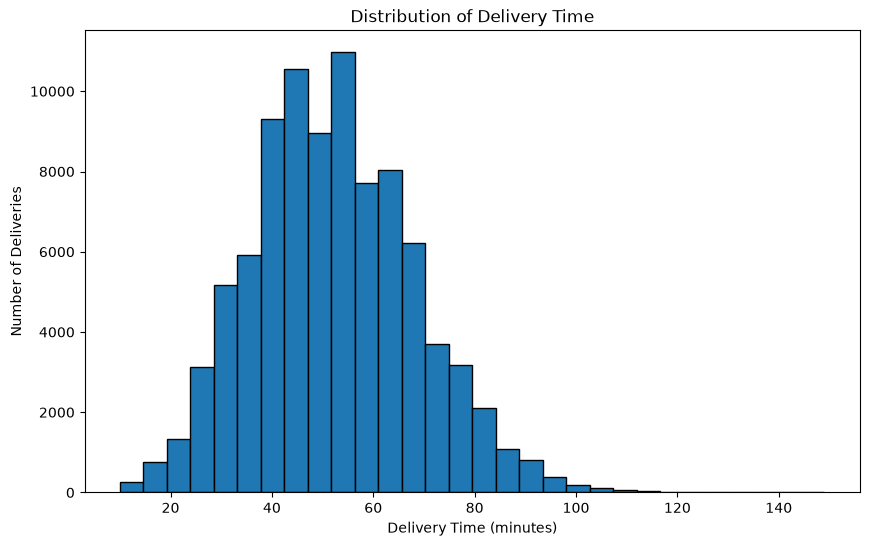

In [9]:
# ============================================
# DAY 4 - PART 1: EDA
# TARGET DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

# Summary statistics
print("Delivery Time Summary:")
print(model_df["delivery_time_min"].describe())

# Histogram
plt.figure(figsize=(10, 6))

plt.hist(
    model_df["delivery_time_min"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Time")

plt.show()

/tmp/ipykernel_121612/869168818.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


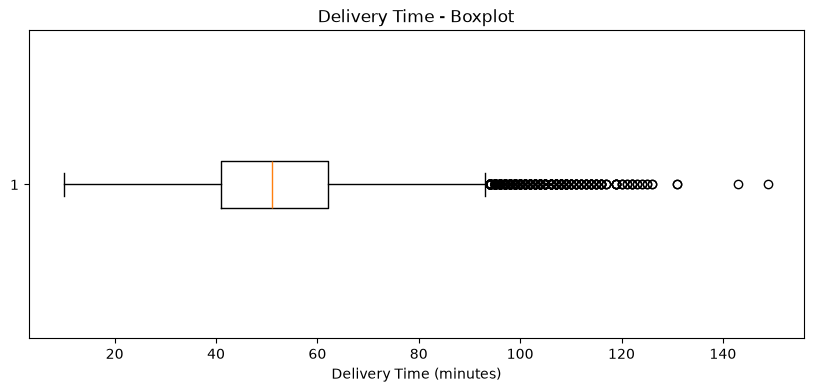

In [10]:
# ============================================
# DELIVERY TIME BOXPLOT
# ============================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    model_df["delivery_time_min"],
    vert=False
)

plt.xlabel("Delivery Time (minutes)")
plt.title("Delivery Time - Boxplot")

plt.show()

In [11]:
# ============================================
# IQR OUTLIER DETECTION
# ============================================

Q1 = model_df["delivery_time_min"].quantile(0.25)
Q3 = model_df["delivery_time_min"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = model_df[
    (model_df["delivery_time_min"] < lower_bound) |
    (model_df["delivery_time_min"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(model_df) * 100, 2), "%")

Q1: 41.0
Q3: 62.0
IQR: 21.0

Lower bound: 9.5
Upper bound: 93.5

Number of outliers: 787
Outlier percentage: 0.87 %


In [12]:
# ============================================
# CORRELATION WITH DELIVERY TIME
# ============================================

numerical_features = [
    "delivery_distance_km",
    "preparation_time_min",
    "order_amount",
    "item_count",
    "hour",
    "day_of_week",
    "restaurant_rating",
    "avg_prep_time",
    "delivery_time_min"
]

correlation_matrix = model_df[numerical_features].corr()

print(
    correlation_matrix["delivery_time_min"]
    .sort_values(ascending=False)
)

delivery_time_min       1.000000
delivery_distance_km    0.488177
preparation_time_min    0.461604
avg_prep_time           0.436684
hour                    0.121031
day_of_week            -0.000952
item_count             -0.002494
order_amount           -0.002693
restaurant_rating      -0.023393
Name: delivery_time_min, dtype: float64


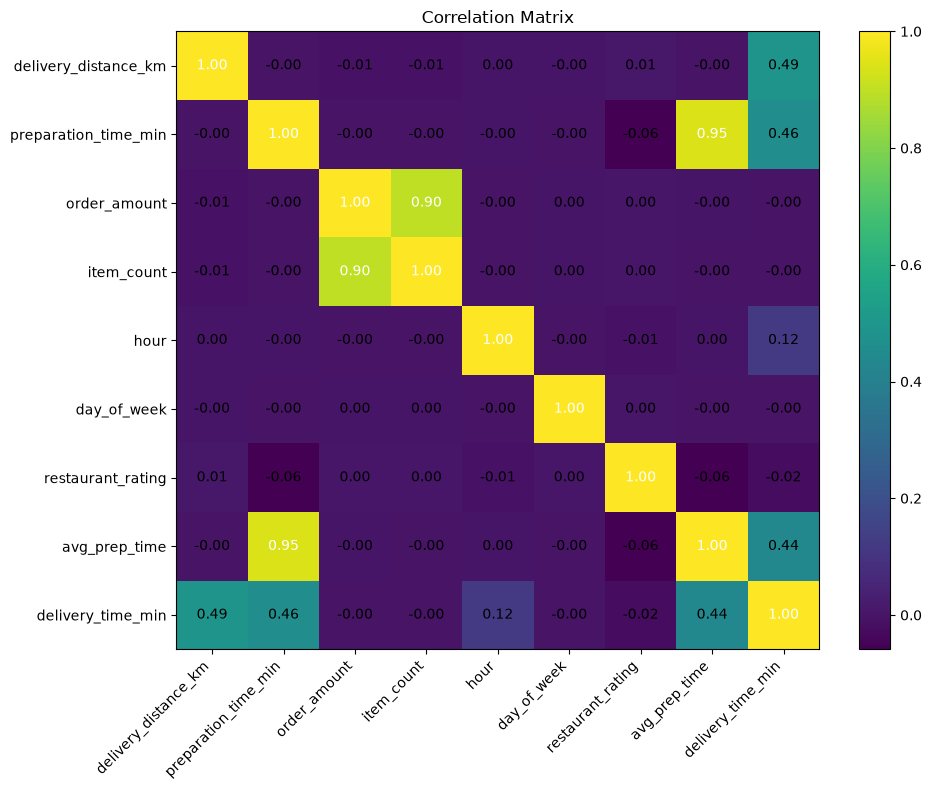

In [23]:
# ============================================
# CORRELATION HEATMAP
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

# Add numeric annotations to each cell
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(correlation_matrix.iloc[i, j]) > 0.5 else "black",
        )

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


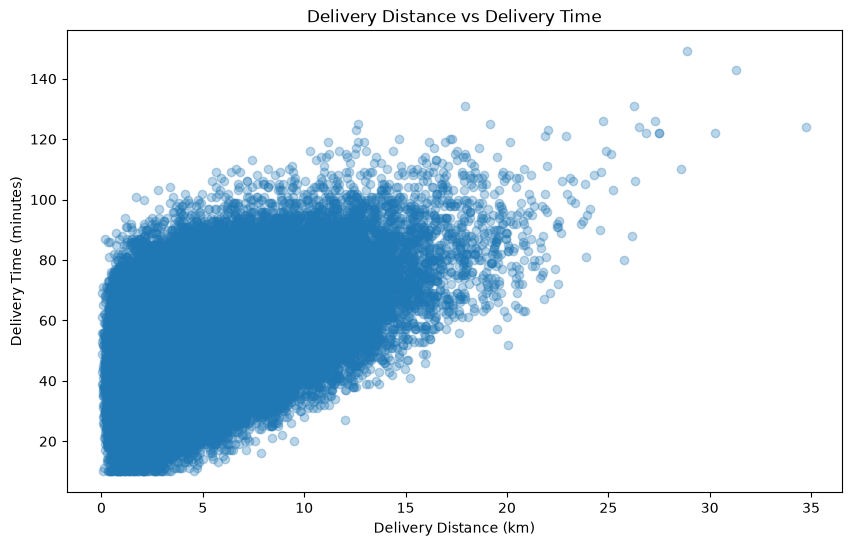

In [18]:
# ============================================
# DISTANCE VS DELIVERY TIME
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    model_df["delivery_distance_km"],
    model_df["delivery_time_min"],
    alpha=0.3
)

plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Distance vs Delivery Time")

plt.show()

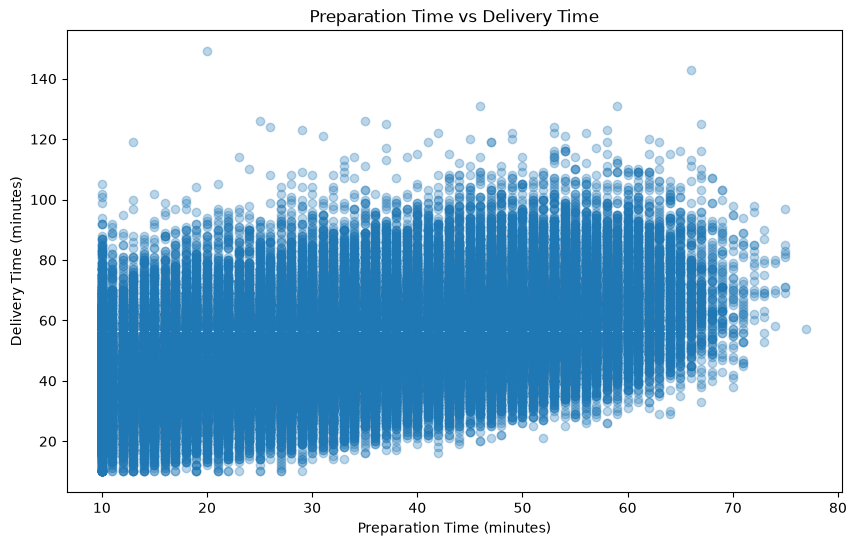

In [19]:
# ============================================
# PREPARATION TIME VS DELIVERY TIME
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    model_df["preparation_time_min"],
    model_df["delivery_time_min"],
    alpha=0.3
)

plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Preparation Time vs Delivery Time")

plt.show()

In [20]:
# ============================================
# DELIVERY TIME BY TRAFFIC CONDITION
# ============================================

print(
    model_df.groupby("traffic_condition")["delivery_time_min"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

                   count       mean  median        std
traffic_condition                                     
High               17792  67.518660    67.0  13.574729
Medium             40618  52.710719    52.0  13.366022
Low                31592  42.756046    42.0  13.371898


In [21]:
# ============================================
# DELIVERY TIME BY WEATHER
# ============================================

print(
    model_df.groupby("weather")["delivery_time_min"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

         count       mean  median        std
weather                                     
Stormy    2838  68.911557    68.0  15.844980
Rainy    15075  59.072504    58.0  15.469143
Cloudy   22400  51.995670    51.0  15.403075
Clear    49689  49.150778    48.0  15.269743


In [22]:
# ============================================
# DELIVERY TIME BY HOUR
# ============================================

hourly_delivery = (
    model_df
    .groupby("hour")["delivery_time_min"]
    .agg(["count", "mean", "median"])
)

display(hourly_delivery)

,count,mean,median
hour,,,
0,2649,47.269536,47.0
1,752,47.406915,46.5
2,806,46.646402,45.0
3,775,47.121290,47.0
4,776,47.654639,46.0
5,799,47.454318,47.0
6,809,47.228677,47.0
7,2654,47.633760,47.0
8,2608,46.827454,46.0


In [24]:
# ============================================
# DAY 4 - PART 2: TRAIN / TEST SPLIT
# BASELINE MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features and target
X = model_df.drop(columns=["delivery_time_min"])
y = model_df["delivery_time_min"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Baseline model
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

# Predictions
baseline_pred = baseline_model.predict(X_test)

# Evaluation
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nBaseline Model Performance")
print("-" * 35)
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Training samples: 72001
Testing samples: 18001

Baseline Model Performance
-----------------------------------
MAE  : 12.9349
RMSE : 16.1913
R²   : -0.0001


In [25]:
# ============================================
# PREPROCESSING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical and categorical features
numeric_features = [
    "delivery_distance_km",
    "preparation_time_min",
    "order_amount",
    "item_count",
    "hour",
    "day_of_week",
    "restaurant_rating",
    "avg_prep_time"
]

categorical_features = [
    "traffic_condition",
    "weather",
    "price_range",
    "cuisine"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing setup complete.")

Preprocessing setup complete.


In [26]:
# ============================================
# RIDGE REGRESSION
# ============================================

from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

# Train
ridge_model.fit(X_train, y_train)

# Predict
ridge_pred = ridge_model.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("-" * 35)
print(f"MAE  : {ridge_mae:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression Performance
-----------------------------------
MAE  : 4.7928
RMSE : 5.9970
R²   : 0.8628


In [27]:
# ============================================
# LASSO REGRESSION
# ============================================

from sklearn.linear_model import Lasso

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]
)

# Train
lasso_model.fit(X_train, y_train)

# Predict
lasso_pred = lasso_model.predict(X_test)

# Evaluate
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Performance")
print("-" * 35)
print(f"MAE  : {lasso_mae:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"R²   : {lasso_r2:.4f}")

Lasso Regression Performance
-----------------------------------
MAE  : 4.7925
RMSE : 5.9973
R²   : 0.8628


In [28]:
# ============================================
# DAY 4 - PART 3: RANDOM FOREST REGRESSION
# ============================================

from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train
random_forest_model.fit(X_train, y_train)

# Predict
rf_pred = random_forest_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 4.3324
RMSE : 5.4652
R²   : 0.8861


In [29]:
# ============================================
# DAY 4 - PART 4: 5-FOLD CROSS-VALIDATION
# ============================================

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Random Forest": random_forest_model
}

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    mae_scores = -scores

    cv_results.append({
        "Model": model_name,
        "CV MAE Mean": mae_scores.mean(),
        "CV MAE Std": mae_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values("CV MAE Mean")
)

,Model,CV MAE Mean,CV MAE Std
2,Random Forest,4.420746,0.019295
0,Ridge,4.811421,0.031777
1,Lasso,4.811622,0.031831


In [31]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Ridge",
        "Lasso",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        lasso_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        ridge_r2,
        lasso_r2,
        rf_r2
    ]
})

comparison = comparison.sort_values("MAE")

display(comparison.round(4))

,Model,MAE,RMSE,R2
3,Random Forest,4.3324,5.4652,0.8861
2,Lasso,4.7925,5.9973,0.8628
1,Ridge,4.7928,5.9970,0.8628
0,Baseline,12.9349,16.1913,-0.0001


In [32]:
# ============================================
# DAY 4 - PART 5: FEATURE IMPORTANCE
# ============================================

# Get the fitted preprocessor from the Random Forest pipeline
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importances = random_forest_model.named_steps["model"].feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 features:")
display(feature_importance_df.head(15))

Top 15 features:


,Feature,Importance
0,num__delivery_distance_km,0.264296
1,cat__traffic_condition_High,0.225920
2,num__preparation_time_min,0.223347
3,num__hour,0.053281
4,cat__traffic_condition_Low,0.039668
5,cat__traffic_condition_Medium,0.036166
6,cat__weather_Clear,0.032217
7,cat__weather_Cloudy,0.021407
8,num__order_amount,0.015458
9,cat__weather_Stormy,0.015209


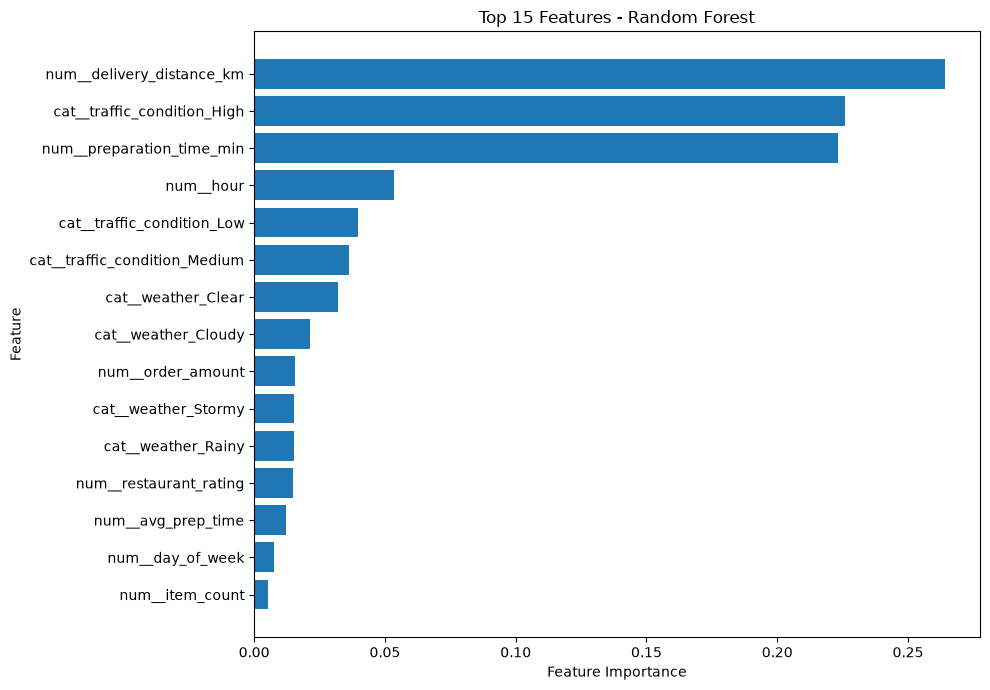

In [33]:
# ============================================
# TOP 15 FEATURE IMPORTANCES
# ============================================

top_features = feature_importance_df.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")

plt.tight_layout()
plt.show()

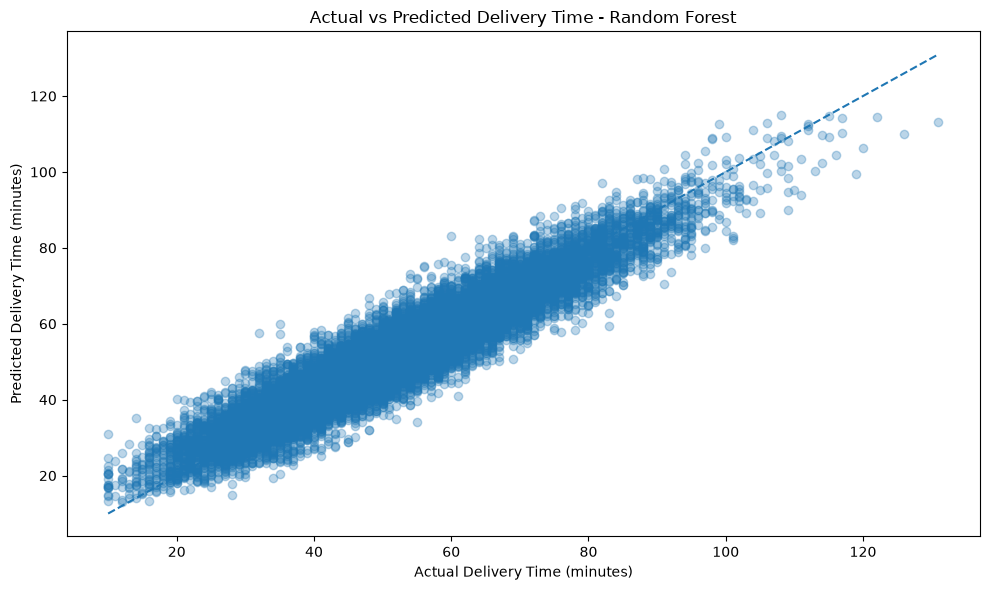

In [34]:
# ============================================
# ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

# Perfect prediction line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time - Random Forest")

plt.tight_layout()
plt.show()

In [35]:
# ============================================
# OVERFITTING CHECK
# ============================================

rf_train_pred = random_forest_model.predict(X_train)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest - Training Performance")
print("-" * 40)
print(f"MAE  : {rf_train_mae:.4f}")
print(f"RMSE : {rf_train_rmse:.4f}")
print(f"R²   : {rf_train_r2:.4f}")

print("\nRandom Forest - Test Performance")
print("-" * 40)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest - Training Performance
----------------------------------------
MAE  : 1.6260
RMSE : 2.0597
R²   : 0.9835

Random Forest - Test Performance
----------------------------------------
MAE  : 4.3324
RMSE : 5.4652
R²   : 0.8861


In [36]:
# ============================================
# SAVE FEATURE-ENGINEERED DATASET
# ============================================

feature_engineered_path = "../data/processed/delivery_time_features.csv"

model_df.to_csv(
    feature_engineered_path,
    index=False
)

print(f"Saved feature-engineered dataset to: {feature_engineered_path}")
print("Shape:", model_df.shape)

Saved feature-engineered dataset to: ../data/processed/delivery_time_features.csv
Shape: (90002, 13)


In [37]:
# ============================================
# SAVE MODEL COMPARISON
# ============================================

comparison_path = "../data/processed/delivery_time_model_comparison.csv"

comparison.to_csv(
    comparison_path,
    index=False
)

print(f"Saved model comparison to: {comparison_path}")

Saved model comparison to: ../data/processed/delivery_time_model_comparison.csv


In [38]:
# ============================================
# SAVE FEATURE IMPORTANCE
# ============================================

importance_path = "../data/processed/delivery_time_feature_importance.csv"

feature_importance_df.to_csv(
    importance_path,
    index=False
)

print(f"Saved feature importance to: {importance_path}")

Saved feature importance to: ../data/processed/delivery_time_feature_importance.csv
